# **Lab 05.1 - Continuous and Policy-Based RL with DDPG and PPO**

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This notebook covers:
- **MountainCarContinuous-v0** for **DDPG (From Scratch)** and **TD3 (Stable-Baselines3)**
- **CartPole-v1** for **PPO (From Scratch)** and **PPO (Stable-Baselines3)**

### Imports and Setup

The following cell configures the runtime and defines shared utilities used across all parts of this lab.

In [1]:
# Runtime stability settings for notebook environments on macOS
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# Keep CPU thread usage predictable in notebook kernels
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

try:
    from stable_baselines3 import PPO as SB3PPO, TD3
    from stable_baselines3.common.noise import NormalActionNoise
    sb3_library_available = True
except Exception:
    SB3PPO = None
    TD3 = None
    NormalActionNoise = None
    sb3_library_available = False

# Reproducibility settings
SEED = 42
FAST_MODE = True

# Set seeds for all libraries to ensure reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': 0.25})

print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

Device: cpu
PyTorch: 2.11.0+cpu
NumPy: 2.4.2
Gymnasium: 1.2.3
FAST_MODE: True


In [2]:
def moving_average_curve(raw_values, window_size=10):
    values_array = np.asarray(raw_values, dtype=np.float32)
    if len(values_array) < window_size:
        return values_array
    kernel_array = np.ones(window_size, dtype=np.float32) / window_size
    return np.convolve(values_array, kernel_array, mode='valid')


def plot_training_curve(training_values, title_text, y_label_text='Return', window_size=10):
    plt.figure(figsize=(8.5, 3.8))
    plt.plot(training_values, alpha=0.35, label='Raw')
    averaged_values = moving_average_curve(training_values, window_size=window_size)
    if len(averaged_values) > 0:
        x_index_values = np.arange(window_size - 1, window_size - 1 + len(averaged_values))
        plt.plot(x_index_values, averaged_values, linewidth=2.0, label=f'MA({window_size})')
    plt.title(title_text)
    plt.xlabel('Episode / Epoch')
    plt.ylabel(y_label_text)
    plt.legend()
    plt.show()


def evaluate_policy_returns(environment_name, policy_action_function, episode_count=8, seed_offset_value=1000):
    episodic_return_values = []
    for episode_index in range(episode_count):
        evaluation_env_instance = gym.make(environment_name)
        current_state, _ = evaluation_env_instance.reset(seed=SEED + seed_offset_value + episode_index)
        episode_done_flag = False
        total_episode_return = 0.0
        while not episode_done_flag:
            selected_action = policy_action_function(current_state)
            next_state, reward_value, terminated_flag, truncated_flag, _ = evaluation_env_instance.step(selected_action)
            total_episode_return += reward_value
            current_state = next_state
            episode_done_flag = terminated_flag or truncated_flag
        episodic_return_values.append(total_episode_return)
        evaluation_env_instance.close()
    return np.asarray(episodic_return_values, dtype=np.float32)

## Part 1: Continuous Control via Deep Deterministic Policy Gradient (DDPG)

### 1.1. Environment Exploration & Continuous Replay Buffer

**Pipeline Architecture**:
1. Initialize `mountaincar_continuous_env` and inspect state/action dimensions.
2. Collect transitions `(s_t, a_t, r_t, s_{t+1}, done_t)` while interacting with the environment.
3. Push each transition into `ContinuousReplayBuffer`.
4. Sample mini-batches for gradient updates in later cells.

**Component Interactions**:
- This environment cell defines action bounds used by actor output scaling.
- `ContinuousReplayBuffer` is consumed directly by the DDPG trainer update routine.

**Mathematical/Algorithmic Anchors**:
- Off-policy stochastic gradient estimation from sampled replay batches.
- Temporal-difference target construction in downstream DDPG updates.

In [3]:
# Probe the MountainCarContinuous-v0 environment to understand its observation and action spaces, as well as reward structure
mountaincar_continuous_env = 'MountainCarContinuous-v0'
mountaincar_probe_env = gym.make(mountaincar_continuous_env)
probe_observation, _ = mountaincar_probe_env.reset(seed=SEED)
sample_continuous_action = mountaincar_probe_env.action_space.sample()
_, probe_reward, probe_terminated, probe_truncated, _ = mountaincar_probe_env.step(sample_continuous_action)

print('Environment:', mountaincar_continuous_env)
print('Observation shape:', mountaincar_probe_env.observation_space.shape)
print('Action shape:', mountaincar_probe_env.action_space.shape)
print('Sample reward:', probe_reward)
print('Episode done from sample step:', probe_terminated or probe_truncated)

mountaincar_probe_env.close()

Environment: MountainCarContinuous-v0
Observation shape: (2,)
Action shape: (1,)
Sample reward: -0.05333948671932696
Episode done from sample step: False


In [9]:
# Define a replay buffer class for storing and sampling transitions during training 
class ContinuousReplayBuffer:
    def __init__(self, buffer_capacity=100000):
        self.transition_buffer = deque(maxlen=buffer_capacity)

    def push(self, state, action, reward, next_state, done):
        # Store a transition tuple in the replay buffer
        self.transition_buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size=128):
        # Randomly sample a batch of transitions from the replay buffer and convert them to PyTorch tensors
        sampled_indices = np.random.choice(len(self.transition_buffer), batch_size, replace=False)
        # Retrieve the sampled transitions and unzip them into separate arrays for states, actions, rewards, next states, and done flags
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        sampled_batch = [self.transition_buffer[index] for index in sampled_indices]
        states_array, actions_array, rewards_array, next_states_array, dones_array = zip(*sampled_batch)
        
        return (
            torch.tensor(states_array, dtype=torch.float32, device=device),
            torch.tensor(actions_array, dtype=torch.float32, device=device),
            torch.tensor(rewards_array, dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(next_states_array, dtype=torch.float32, device=device),
            torch.tensor(dones_array, dtype=torch.float32, device=device).unsqueeze(1),
        )

    def __len__(self):
        return len(self.transition_buffer)

### 1.2. DDPG Network Architectures (From Scratch)

**Pipeline Architecture**:
1. Define two neural architectures only: `DDPGActor` and `DDPGCritic`.
2. Instantiate four network objects: `ddpg_online_actor`, `ddpg_target_actor`, `ddpg_online_critic`, `ddpg_target_critic`.
3. Copy online parameters to target parameters before training.
4. Use online networks for gradient updates and target networks for stable TD targets.

**Component Interactions**:
- `ddpg_online_actor` proposes actions for current states.
- `ddpg_online_critic` evaluates `(state, action)` pairs and receives gradients from Bellman errors.
- `ddpg_target_actor` and `ddpg_target_critic` are queried only for TD target computation.

**Mathematical/Algorithmic Anchors**:
- Stable target equation: $y_i = r_i + \gamma Q_{target}(s_{i+1}, \mu_{target}(s_{i+1}))$.
- Deterministic policy gradient updates actor via $\nabla_a Q(s,a) |_{a=\mu(s)}$.

**Why 2 definitions but 4 instances?**
- The architecture classes define *parameterized functions* only once.
- Two online instances are trainable and move every update step.
- Two target instances change slowly with soft updates to avoid moving-target divergence during TD learning.

In [10]:
class DDPGActor(nn.Module):
    def __init__(self, state_dimension, action_dimension, max_action_magnitude, hidden_size=256):
        super().__init__()
        # max_action_magnitude is used to scale the output of the actor network to ensure it falls within the valid action range of the environment. 
        self.max_action_magnitude = max_action_magnitude
        self.actor_network = nn.Sequential(
            # Architechture of the actor network:
            # Linear (state_dimension -> hidden_size) -> ReLU -> Linear (hidden_size -> hidden_size) -> ReLU -> Linear (hidden_size -> action_dimension) -> Tanh
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            nn.Linear(state_dimension, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),            
            nn.Linear(hidden_size, action_dimension),
            nn.Tanh(),
            
        )
        # The final layer uses Tanh activation, which outputs values in the range [-1, 1]. 

    def forward(self, state_tensor):
        # By multiplying with max_action_magnitude, we can scale this output to match the action space of the environment.
        return self.max_action_magnitude * self.actor_network(state_tensor)



class DDPGCritic(nn.Module):
    def __init__(self, state_dimension, action_dimension, hidden_size=256):
        super().__init__()
        self.critic_network = nn.Sequential(
            # The critic network takes both the state and action as input, 
            # so we concatenate them along the feature dimension (dim=1) before passing through the network.
            # Architechture of the critic network:
            # Linear (state_dimension + action_dimension -> hidden_size) -> ReLU -> Linear (hidden_size -> hidden_size) -> ReLU -> Linear (hidden_size -> 1)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            nn.Linear(state_dimension + action_dimension, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            
        )

    def forward(self, state_tensor, action_tensor):
        # Concatenate the state and action tensors along the feature dimension (dim=1) 
        # before passing through the critic network to get the Q-value estimate for that state-action pair.
        return self.critic_network(torch.cat([state_tensor, action_tensor], dim=1))


env = gym.make(mountaincar_continuous_env)
# Extract the dimensions of the state and action spaces, 
ddpg_state_dimension = env.observation_space.shape[0]
ddpg_action_dimension = env.action_space.shape[0]
# The maximum action value is determined by the environment's action space, 
# which is typically symmetric around zero for continuous control tasks.
ddpg_max_action_value = float(env.action_space.high[0])
env.close()

# Initialize the online and target networks for both the actor and critic
### YOU NEED TO WRITE YOUR CODE BELOW ###
ddpg_online_actor = DDPGActor(state_dimension=ddpg_state_dimension, action_dimension=ddpg_action_dimension, max_action_magnitude=ddpg_max_action_value).to(device)
ddpg_target_actor = DDPGActor(state_dimension=ddpg_state_dimension, action_dimension=ddpg_action_dimension, max_action_magnitude=ddpg_max_action_value).to(device)
ddpg_online_critic = DDPGCritic(state_dimension=ddpg_state_dimension, action_dimension=ddpg_action_dimension).to(device)
ddpg_target_critic = DDPGCritic(state_dimension=ddpg_state_dimension, action_dimension=ddpg_action_dimension).to(device)

# Copy the weights from the online networks to the target networks
### YOU NEED TO WRITE YOUR CODE BELOW ###
ddpg_target_actor.load_state_dict(ddpg_online_actor.state_dict())
ddpg_target_critic.load_state_dict(ddpg_online_critic.state_dict())

ddpg_actor_optimizer = optim.Adam(ddpg_online_actor.parameters(), lr=1e-4)
ddpg_critic_optimizer = optim.Adam(ddpg_online_critic.parameters(), lr=1e-3)
ddpg_replay_buffer = ContinuousReplayBuffer(buffer_capacity=120000)

print('DDPG actor and critic instances initialized successfully.')

DDPG actor and critic instances initialized successfully.


### 1.3. Exploration Noise & Training Loop

**Pipeline Architecture**:
1. Actor emits deterministic continuous action.
2. Add Gaussian exploration noise during training.
3. Store transition in replay buffer.
4. Sample batch and compute critic target using target actor/critic.
5. Update online critic then online actor.
6. Soft-update target parameters with $\theta' \leftarrow \tau\theta + (1-\tau)\theta'$.

**Component Interactions**:
- Training environment drives data collection.
- Replay buffer decouples data collection from optimization.
- Optimizers update online networks; target networks track online networks smoothly.

**Mathematical/Algorithmic Anchors**:
- Critic MSE loss between $Q_{online}(s_t, a_t)$ and TD target $y_t$.
- Actor objective maximizes critic estimate $Q(s, \mu(s))$ via minimizing negative mean Q.

In [ ]:
class GaussianExplorationNoise:
    def __init__(self, action_dimension, sigma_value=0.22):
        self.action_dimension = action_dimension
        self.sigma_value = sigma_value

    def sample(self):
        # Generate Gaussian noise with mean 0 and standard deviation sigma_value for each action dimension.
        return np.random.normal(0.0, self.sigma_value, size=self.action_dimension)


class DDPGTrainer:
    def __init__(self):
        self.discount_gamma = 0.99
        self.soft_update_tau = 0.005
        self.batch_size = 64
        self.start_training_after = 256
        self.gradient_updates_per_step = 1
        self.exploration_noise = GaussianExplorationNoise(ddpg_action_dimension, sigma_value=0.22)

    def update_noise_scale(self, episode_progress_ratio):
        # Linearly decay noise so the learned policy becomes near-deterministic near the end.
        min_sigma = 0.02
        max_sigma = 0.22
        progress_clipped = np.clip(episode_progress_ratio, 0.0, 1.0)
        self.exploration_noise.sigma_value = max_sigma - (max_sigma - min_sigma) * progress_clipped

    def select_action(self, state_vector, training_mode=True):
        state_tensor = torch.tensor(state_vector, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            deterministic_action = ddpg_online_actor(state_tensor).cpu().numpy()[0]
        if training_mode:
            deterministic_action = deterministic_action + self.exploration_noise.sample()
        clipped_action = np.clip(deterministic_action, -ddpg_max_action_value, ddpg_max_action_value)
        return clipped_action

    def soft_update_target_network(self, online_network, target_network):
        for online_parameter, target_parameter in zip(online_network.parameters(), target_network.parameters()):
            target_parameter.data.copy_(
                self.soft_update_tau * online_parameter.data + (1.0 - self.soft_update_tau) * target_parameter.data
            )

    def train_step(self):
        if len(ddpg_replay_buffer) < max(self.batch_size, self.start_training_after):
            return

        for _ in range(self.gradient_updates_per_step):
            sampled_states, sampled_actions, sampled_rewards, sampled_next_states, sampled_dones = ddpg_replay_buffer.sample(self.batch_size)

            with torch.no_grad():
                target_actions = ddpg_target_actor(sampled_next_states)
                target_q_values = ddpg_target_critic(sampled_next_states, target_actions)
                td_target_values = sampled_rewards + self.discount_gamma * (1.0 - sampled_dones) * target_q_values

            current_q_values = ddpg_online_critic(sampled_states, sampled_actions)
            critic_loss_value = nn.MSELoss()(current_q_values, td_target_values)
            ddpg_critic_optimizer.zero_grad()
            critic_loss_value.backward()
            ddpg_critic_optimizer.step()

            actor_loss_value = -ddpg_online_critic(sampled_states, ddpg_online_actor(sampled_states)).mean()
            ddpg_actor_optimizer.zero_grad()
            actor_loss_value.backward()
            ddpg_actor_optimizer.step()

            self.soft_update_target_network(ddpg_online_actor, ddpg_target_actor)
            self.soft_update_target_network(ddpg_online_critic, ddpg_target_critic)


# Speed-oriented defaults for this lab notebook.
DDPG_QUICK_MODE = True

# Reinitialize optimizers for this tuned training run.
ddpg_actor_optimizer = optim.Adam(ddpg_online_actor.parameters(), lr=3e-4)
ddpg_critic_optimizer = optim.Adam(ddpg_online_critic.parameters(), lr=1e-3)

ddpg_trainer = DDPGTrainer()
ddpg_train_max_steps = 450 if DDPG_QUICK_MODE else 700
ddpg_training_environment = gym.make(mountaincar_continuous_env, max_episode_steps=ddpg_train_max_steps)
ddpg_episode_count = 70 if DDPG_QUICK_MODE else 130
ddpg_training_returns = []
ddpg_training_success_flags = []

for ddpg_episode_index in range(ddpg_episode_count):
    ddpg_trainer.update_noise_scale(ddpg_episode_index / max(ddpg_episode_count - 1, 1))
    episode_state, _ = ddpg_training_environment.reset(seed=SEED + ddpg_episode_index)
    episode_done = False
    episode_return_value = 0.0
    episode_success_flag = 0

    while not episode_done:
        selected_action = ddpg_trainer.select_action(episode_state, training_mode=True)
        next_state, reward_value, terminated_flag, truncated_flag, _ = ddpg_training_environment.step(selected_action)
        transition_done = float(terminated_flag or truncated_flag)
        ddpg_replay_buffer.push(episode_state, selected_action, reward_value, next_state, transition_done)
        ddpg_trainer.train_step()

        if terminated_flag:
            episode_success_flag = 1

        episode_state = next_state
        episode_return_value += reward_value
        episode_done = terminated_flag or truncated_flag

    ddpg_training_returns.append(episode_return_value)
    ddpg_training_success_flags.append(episode_success_flag)

    if (ddpg_episode_index + 1) % 10 == 0:
        recent_window = ddpg_training_success_flags[-20:]
        recent_success_rate = float(np.mean(recent_window)) if len(recent_window) > 0 else 0.0
        print(
            f"[DDPG] Episode {ddpg_episode_index + 1}/{ddpg_episode_count} "
            f"Return={episode_return_value:.2f} "
            f"NoiseSigma={ddpg_trainer.exploration_noise.sigma_value:.3f} "
            f"RecentSuccess(20)={recent_success_rate:.2%}"
        )

    # Early stop when policy is already stable to save runtime.
    if len(ddpg_training_success_flags) >= 20:
        if np.mean(ddpg_training_success_flags[-20:]) >= 0.85 and (ddpg_episode_index + 1) >= 45:
            print(f"Early stop at episode {ddpg_episode_index + 1}: recent success >= 85%.")
            break

ddpg_training_environment.close()
plot_training_curve(ddpg_training_returns, 'DDPG Training on MountainCarContinuous-v0', window_size=10)

In [ ]:
def evaluate_ddpg_success_rate(
    environment_name,
    trained_trainer,
    episode_count=100,
    seed_offset_value=4000,
    eval_max_steps=500,
):
    success_counter = 0

    eval_env = gym.make(environment_name, max_episode_steps=eval_max_steps)
    goal_position = float(eval_env.unwrapped.goal_position)

    for episode_index in range(episode_count):
        state_vector, _ = eval_env.reset(seed=SEED + seed_offset_value + episode_index)
        episode_done = False
        episode_success = False

        while not episode_done:
            action_vector = trained_trainer.select_action(state_vector, training_mode=False)
            next_state_vector, _, terminated_flag, truncated_flag, _ = eval_env.step(action_vector)

            if terminated_flag and next_state_vector[0] >= goal_position:
                episode_success = True

            state_vector = next_state_vector
            episode_done = terminated_flag or truncated_flag

        if episode_success:
            success_counter += 1

    eval_env.close()

    success_rate_value = success_counter / episode_count
    return success_rate_value, success_counter, episode_count


ddpg_success_rate, ddpg_success_count, ddpg_eval_episodes = evaluate_ddpg_success_rate(
    mountaincar_continuous_env,
    ddpg_trainer,
    episode_count=100,
    seed_offset_value=4000,
    eval_max_steps=500,
)

target_success_rate = 0.80
print(
    f"DDPG Success Rate (100 episodes): {ddpg_success_rate:.2%} "
    f"({ddpg_success_count}/{ddpg_eval_episodes} episodes reached the goal)"
)

if ddpg_success_rate >= target_success_rate:
    print("Target reached: success rate is above 80%.")
else:
    print("Target not reached yet: switch DDPG_QUICK_MODE=False for a longer training run.")

DDPG Success Rate: 0.00% (0/20 episodes reached the goal)


## Part 2: Advanced Continuous Control via Twin Delayed DDPG (TD3)

### 2.1. TD3 Implementation via Stable-Baselines3

**Pipeline Architecture**:
1. Initialize `td3_training_environment` using `mountaincar_continuous_env`.
2. Configure TD3 with action noise and twin-critic internals (provided by SB3).
3. Learn policy parameters over a fixed timesteps budget.

**Component Interactions**:
- SB3 TD3 baseline reuses the same environment setting as DDPG for fair comparison.
- Evaluator cell directly compares DDPG and TD3 under consistent seeds.

**Mathematical/Algorithmic Anchors**:
- Twin-critic min target in TD3 addresses Q overestimation.
- Delayed policy updates reduce actor overfitting to critic noise.

In [ ]:
if sb3_library_available:
    td3_training_environment = gym.make(mountaincar_continuous_env)
    td3_action_dimension = td3_training_environment.action_space.shape[0]
    td3_action_noise = NormalActionNoise(mean=np.zeros(td3_action_dimension), sigma=0.1 * np.ones(td3_action_dimension))

    td3_sb3_model = TD3(
        'MlpPolicy',
        td3_training_environment,
        learning_rate=1e-3,
        buffer_size=50000,
        batch_size=128,
        gamma=0.99,
        tau=0.005,
        policy_delay=2,
        action_noise=td3_action_noise,
        seed=SEED,
        verbose=0,
        device=device,
    )
    td3_training_timesteps = 6000 if FAST_MODE else 32000
    td3_sb3_model.learn(total_timesteps=td3_training_timesteps, progress_bar=False)
    td3_training_environment.close()
else:
    td3_sb3_model = None
    print('SB3 not available: TD3 baseline skipped.')

### 2.2. Performance Evaluation & Visualization

**Pipeline Architecture**:
1. Evaluate trained DDPG deterministic policy.
2. Evaluate SB3 TD3 deterministic policy when available.
3. Aggregate means and standard deviations.
4. Produce comparison tables and bar plots (Lab 4 style).

**Component Interactions**:
- Uses shared `evaluate_policy_returns` helper and common seeds.
- Outputs feed into `pandas` table and Matplotlib visualization.

**Mathematical/Algorithmic Anchors**:
- Episodic return expectation approximated by Monte Carlo averaging across seeded episodes.

                mean_return  std_return
DDPG (Scratch)    -0.000196    0.000021
TD3 (SB3)         -0.012517    0.000547


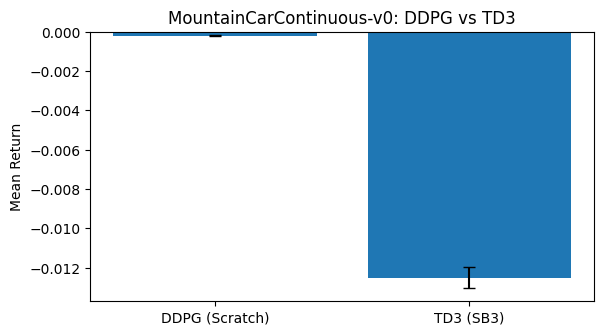

In [20]:
def ddpg_deterministic_action_function(observation_state):
    state_tensor = torch.tensor(observation_state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        deterministic_action = ddpg_online_actor(state_tensor).cpu().numpy()[0]
    return np.clip(deterministic_action, -ddpg_max_action_value, ddpg_max_action_value)


continuous_results_dictionary = {}
ddpg_evaluation_returns = evaluate_policy_returns(
    mountaincar_continuous_env, ddpg_deterministic_action_function, episode_count=10, seed_offset_value=2000
)
continuous_results_dictionary['DDPG (Scratch)'] = {
    'mean_return': float(ddpg_evaluation_returns.mean()),
    'std_return': float(ddpg_evaluation_returns.std()),
}

if td3_sb3_model is not None:
    def td3_deterministic_action_function(observation_state):
        td3_action_value, _ = td3_sb3_model.predict(observation_state, deterministic=True)
        return td3_action_value

    td3_evaluation_returns = evaluate_policy_returns(
        mountaincar_continuous_env, td3_deterministic_action_function, episode_count=10, seed_offset_value=3000
    )
    continuous_results_dictionary['TD3 (SB3)'] = {
        'mean_return': float(td3_evaluation_returns.mean()),
        'std_return': float(td3_evaluation_returns.std()),
    }

continuous_results_frame = pd.DataFrame(continuous_results_dictionary).T
print(continuous_results_frame)

plt.figure(figsize=(6.5, 3.5))
plt.bar(
    continuous_results_frame.index,
    continuous_results_frame['mean_return'],
    yerr=continuous_results_frame['std_return'],
    capsize=4,
)
plt.title('MountainCarContinuous-v0: DDPG vs TD3')
plt.ylabel('Mean Return')
plt.show()